# VDP vs digest2 — 4-panel Direction Comparison

Produces two paper figures across four ecliptic sky directions on 2026 May 9:
- **Figure 1** (`roc_4panel_directions.png/pdf`): ROC curves (completeness vs contamination) for VDP and digest2, 2×2 panel.
- **Figure 2** (`quadrant_4panel_directions.png/pdf`): Log-log score-threshold quadrant scatter, 2×2 panel.

Directions (matching column order in `density_direction_comparison_MBA_NEO_24panel.png`):
- Anti-sun / NEOCP field: lon = 229°, Δ = 0°
- −45° from anti-sun: lon = 183°
- −90° from anti-sun: lon = 138°
- −120° from anti-sun: lon = 108°

Input parquets already contain `P_NEO_vdp` and `P_NEO_d2`; no rescoring needed.

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

_HERE = os.path.abspath('.')

## 2. Run configs

In [2]:
RUNS = [
    dict(
        label      = '2026-05-09T22_neocp',
        title      = 'Anti-sun / NEOCP\n(lon = 229°,  Δ = 0°)',
        parquet    = os.path.join(_HERE, 's3m_digest2_comparison_2026-05-09T22_neocp.parquet'),
        panel_idx  = 0,
    ),
    dict(
        label      = '2026-05-09_antisun_minus_45',
        title      = '−45° from anti-sun\n(lon = 183°)',
        parquet    = os.path.join(_HERE, 's3m_digest2_comparison_2026-05-09_antisun_minus_45.parquet'),
        panel_idx  = 1,
    ),
    dict(
        label      = '2026-05-09_antisun_minus_90',
        title      = '−90° from anti-sun\n(lon = 138°)',
        parquet    = os.path.join(_HERE, 's3m_digest2_comparison_2026-05-09_antisun_minus_90.parquet'),
        panel_idx  = 2,
    ),
    dict(
        label      = '2026-05-09_antisun_minus_120',
        title      = '−120° from anti-sun\n(lon = 108°)',
        parquet    = os.path.join(_HERE, 's3m_digest2_comparison_2026-05-09_antisun_minus_120.parquet'),
        panel_idx  = 3,
    ),
]

POPS   = ['NEO', 'MBA', 'TNO', 'Trojans']
COLORS = {'NEO': 'tab:blue', 'MBA': 'tab:orange', 'TNO': 'tab:green', 'Trojans': 'tab:red'}

## 3. ROC helpers

In [3]:
THRESHOLDS = np.linspace(0, 1, 401)

def compute_roc(scores, is_neo, thresholds):
    n_neo = is_neo.sum()
    comp = np.empty(len(thresholds))
    cont = np.empty(len(thresholds))
    for j, t in enumerate(thresholds):
        above = scores > t
        tp = above[ is_neo].sum()
        fp = above[~is_neo].sum()
        comp[j] = tp / max(n_neo, 1)
        cont[j] = fp / max(tp + fp, 1)
    return comp, cont

def best_f1(comp, cont, thr):
    pur = 1.0 - cont
    f1  = np.where(pur + comp > 0, 2 * pur * comp / (pur + comp + 1e-12), 0.0)
    i   = np.argmax(f1)
    return thr[i], comp[i], cont[i], f1[i]

def max_completeness_at_contamination(comp, cont, thr, contam_limit=0.10):
    """Best completeness among thresholds with nonzero selection and contamination <= limit."""
    valid = np.flatnonzero((cont <= contam_limit) & (comp > 0))
    if len(valid) == 0:
        return np.nan, np.nan, np.nan
    max_comp = comp[valid].max()
    tied = valid[np.isclose(comp[valid], max_comp)]
    i = tied[np.argmin(cont[tied])]
    return thr[i], comp[i], cont[i]

def min_contamination_at_completeness(comp, cont, thr, comp_target=0.70):
    """Lowest contamination among thresholds with completeness >= target."""
    valid = np.flatnonzero(comp >= comp_target)
    if len(valid) == 0:
        return np.nan, np.nan, np.nan
    min_cont = cont[valid].min()
    tied = valid[np.isclose(cont[valid], min_cont)]
    i = tied[np.argmax(comp[tied])]
    return thr[i], comp[i], cont[i]

## 4. Load data and compute ROC for each direction

In [4]:
for run in RUNS:
    df = pd.read_parquet(run['parquet'])
    is_neo = (df['true_population'] == 'NEO').to_numpy()
    n_neo  = is_neo.sum()

    comp_v, cont_v = compute_roc(df['P_NEO_vdp'].to_numpy(), is_neo, THRESHOLDS)
    comp_d, cont_d = compute_roc(df['P_NEO_d2'].to_numpy(),  is_neo, THRESHOLDS)

    tv, cv, nv, fv = best_f1(comp_v, cont_v, THRESHOLDS)
    td, cd, nd, fd = best_f1(comp_d, cont_d, THRESHOLDS)

    run.update(dict(
        df=df, is_neo=is_neo, n_neo=n_neo,
        comp_v=comp_v, cont_v=cont_v,
        comp_d=comp_d, cont_d=cont_d,
        tv=tv, cv=cv, nv=nv, fv=fv,
        td=td, cd=cd, nd=nd, fd=fd,
    ))

    print(f"{run['label']}:  N_NEO={n_neo}  "
          f"VDP F1={fv:.3f} (comp={cv:.1%}, cont={nv:.1%}, t={tv:.3f})  "
          f"d2 F1={fd:.3f} (comp={cd:.1%}, cont={nd:.1%}, t={td:.3f})")

# Fiducial operating-point diagnostics suggested for the paper text/table.
# C@contam<=10% means maximum NEO completeness at any threshold with contamination <= 10%.
# contam@C>=70% means minimum contamination at any threshold with NEO completeness >= 70%.
fiducial_rows = []
for run in RUNS:
    for method, comp_key, cont_key, t_key, c_key, n_key, f_key in [
        ('VDP',     'comp_v', 'cont_v', 'tv', 'cv', 'nv', 'fv'),
        ('digest2', 'comp_d', 'cont_d', 'td', 'cd', 'nd', 'fd'),
    ]:
        t10, c10, n10 = max_completeness_at_contamination(
            run[comp_key], run[cont_key], THRESHOLDS, contam_limit=0.10
        )
        t70, c70, n70 = min_contamination_at_completeness(
            run[comp_key], run[cont_key], THRESHOLDS, comp_target=0.70
        )
        fiducial_rows.append(dict(
            field=run['title'].replace('\n', ' '),
            method=method,
            N_total=len(run['df']),
            N_NEO=int(run['n_neo']),
            best_F1_threshold=run[t_key],
            best_F1=run[f_key],
            best_F1_completeness=run[c_key],
            best_F1_contamination=run[n_key],
            threshold_for_contam_le_10=t10,
            completeness_at_contam_le_10=c10,
            contamination_at_that_threshold=n10,
            threshold_for_comp_ge_70=t70,
            completeness_at_that_threshold=c70,
            contamination_at_comp_ge_70=n70,
        ))

fiducial_metrics = pd.DataFrame(fiducial_rows)

fiducial_metrics_display = fiducial_metrics.copy()
percent_cols = [
    'best_F1_completeness', 'best_F1_contamination',
    'completeness_at_contam_le_10', 'contamination_at_that_threshold',
    'completeness_at_that_threshold', 'contamination_at_comp_ge_70',
]
threshold_cols = ['best_F1_threshold', 'threshold_for_contam_le_10', 'threshold_for_comp_ge_70']
for col in percent_cols:
    fiducial_metrics_display[col] = fiducial_metrics_display[col].map(
        lambda x: 'not reached' if pd.isna(x) else f'{100*x:.1f}%'
    )
for col in threshold_cols:
    fiducial_metrics_display[col] = fiducial_metrics_display[col].map(
        lambda x: 'not reached' if pd.isna(x) else f'{x:.3f}'
    )
fiducial_metrics_display['best_F1'] = fiducial_metrics_display['best_F1'].map(lambda x: f'{x:.3f}')

display(fiducial_metrics_display)

2026-05-09T22_neocp:  N_NEO=1119  VDP F1=0.847 (comp=75.0%, cont=2.7%, t=0.030)  d2 F1=0.655 (comp=52.2%, cont=12.2%, t=0.960)
2026-05-09_antisun_minus_45:  N_NEO=1035  VDP F1=0.710 (comp=63.4%, cont=19.3%, t=0.007)  d2 F1=0.649 (comp=50.7%, cont=9.8%, t=0.890)
2026-05-09_antisun_minus_90:  N_NEO=1149  VDP F1=0.615 (comp=55.8%, cont=31.4%, t=0.013)  d2 F1=0.337 (comp=26.0%, cont=52.0%, t=0.960)
2026-05-09_antisun_minus_120:  N_NEO=1404  VDP F1=0.643 (comp=50.5%, cont=11.5%, t=0.060)  d2 F1=0.339 (comp=28.4%, cont=58.1%, t=0.960)


,field,method,N_total,N_NEO,best_F1_threshold,best_F1,best_F1_completeness,best_F1_contamination,threshold_for_contam_le_10,completeness_at_contam_le_10,contamination_at_that_threshold,threshold_for_comp_ge_70,completeness_at_that_threshold,contamination_at_comp_ge_70
0,"Anti-sun / NEOCP (lon = 229°, Δ = 0°)",VDP,21027,1119,0.030,0.847,75.0%,2.7%,0.018,76.3%,6.7%,0.095,70.1%,1.3%
1,"Anti-sun / NEOCP (lon = 229°, Δ = 0°)",digest2,21027,1119,0.960,0.655,52.2%,12.2%,0.970,50.0%,7.9%,0.390,70.1%,89.2%
2,−45° from anti-sun (lon = 183°),VDP,50631,1035,0.007,0.710,63.4%,19.3%,0.018,54.1%,9.2%,0.003,71.5%,40.5%
3,−45° from anti-sun (lon = 183°),digest2,50631,1035,0.890,0.649,50.7%,9.8%,0.890,50.7%,9.8%,0.250,70.4%,79.3%
4,−90° from anti-sun (lon = 138°),VDP,31038,1149,0.013,0.615,55.8%,31.4%,0.065,42.2%,9.9%,0.000,99.8%,96.3%
5,−90° from anti-sun (lon = 138°),digest2,31038,1149,0.960,0.337,26.0%,52.0%,not reached,not reached,not reached,0.080,70.8%,93.9%
6,−120° from anti-sun (lon = 108°),VDP,17964,1404,0.060,0.643,50.5%,11.5%,0.070,49.4%,9.9%,0.005,72.0%,75.0%
7,−120° from anti-sun (lon = 108°),digest2,17964,1404,0.960,0.339,28.4%,58.1%,not reached,not reached,not reached,0.050,77.7%,89.9%


## 5. Figure 1: ROC curves — 2×2 panel

Each panel: completeness vs contamination for VDP and digest2, with best-F1 operating points annotated.

Saved: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/roc_4panel_directions.png
Saved: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/roc_4panel_directions.pdf


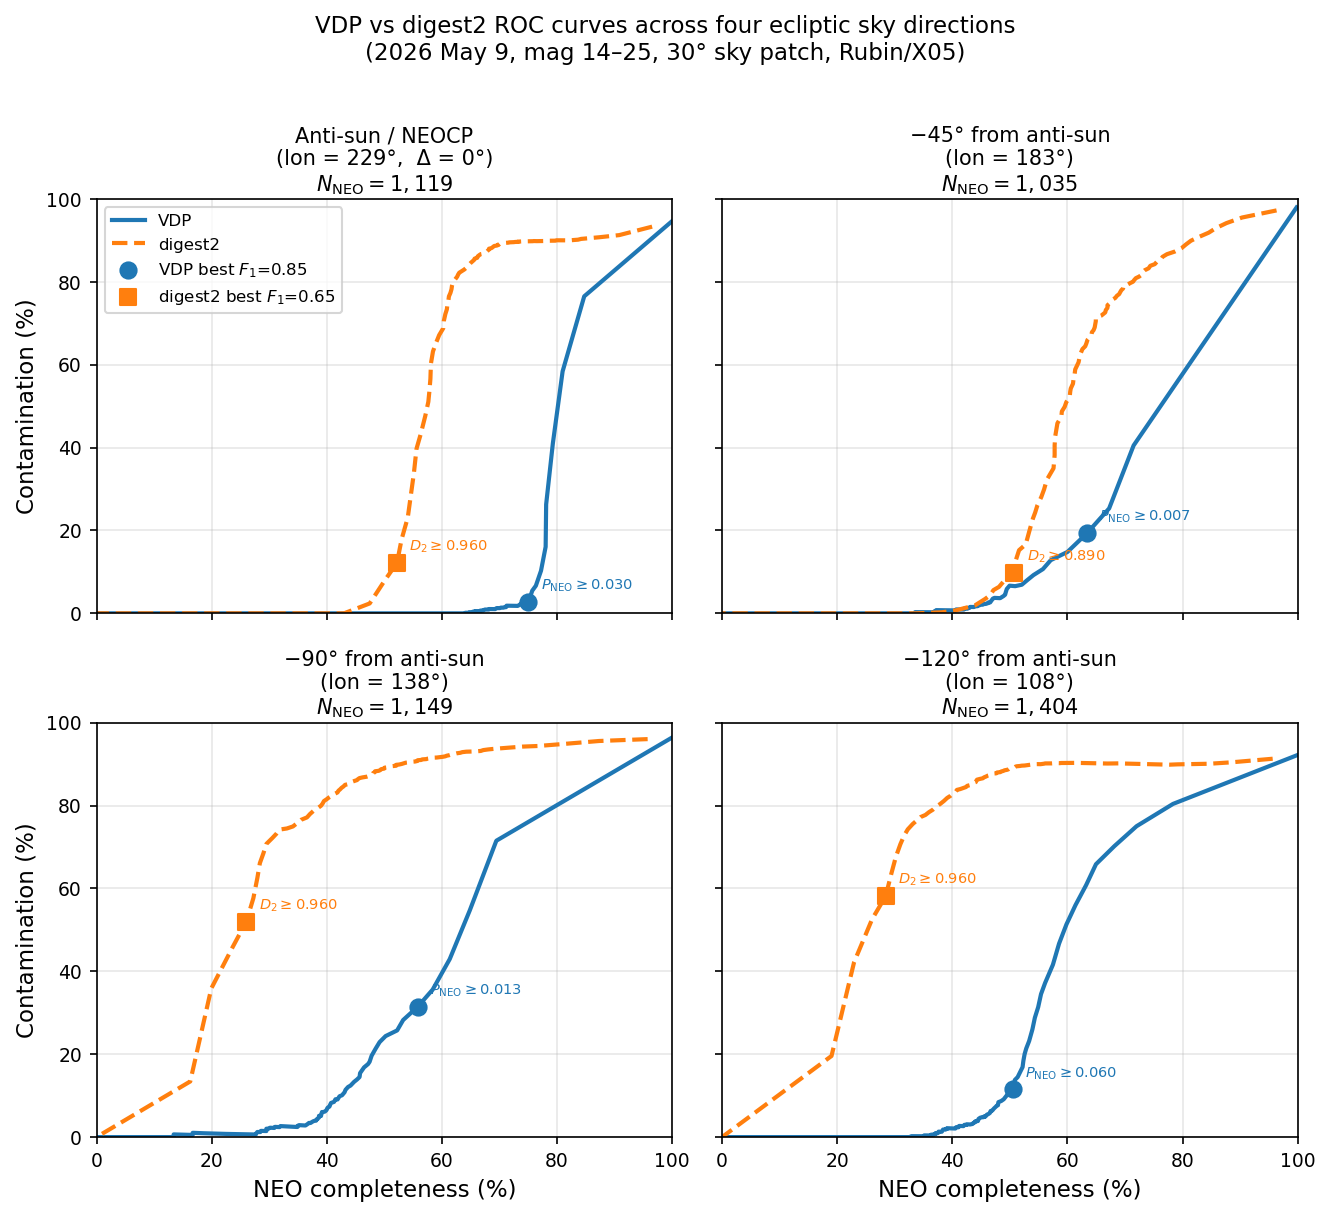

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=True, sharey=True)
axes_flat = axes.flatten()

for run in RUNS:
    ax = axes_flat[run['panel_idx']]
    row, col = divmod(run['panel_idx'], 2)

    ax.plot(run['comp_v'] * 100, run['cont_v'] * 100,
            lw=2.0, color='tab:blue', label='VDP')
    ax.plot(run['comp_d'] * 100, run['cont_d'] * 100,
            lw=2.0, color='tab:orange', linestyle='--', label='digest2')

    ax.scatter([run['cv'] * 100], [run['nv'] * 100],
               color='tab:blue', s=60, zorder=5,
               label=f"VDP best $F_1$={run['fv']:.2f}")
    ax.scatter([run['cd'] * 100], [run['nd'] * 100],
               color='tab:orange', s=60, zorder=5, marker='s',
               label=f"digest2 best $F_1$={run['fd']:.2f}")

    # Annotate best-F1 thresholds
    ax.annotate(
        f'$P_{{\\mathrm{{NEO}}}}\\geq{run["tv"]:.3f}$',
        xy=(run['cv'] * 100, run['nv'] * 100),
        xytext=(6, 6), textcoords='offset points',
        color='tab:blue', fontsize=7,
    )
    ax.annotate(
        f'$D_2\\geq{run["td"]:.3f}$',
        xy=(run['cd'] * 100, run['nd'] * 100),
        xytext=(6, 6), textcoords='offset points',
        color='tab:orange', fontsize=7,
    )

    ax.set_title(f"{run['title']}\n$N_{{\\mathrm{{NEO}}}}={run['n_neo']:,}$", pad=4)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.3)

    # Axis labels: bottom row and left column only
    if row == 1:
        ax.set_xlabel('NEO completeness (%)')
    if col == 0:
        ax.set_ylabel('Contamination (%)')

    # Shared legend on first panel only
    if run['panel_idx'] == 0:
        ax.legend(loc='upper left', frameon=True)

fig.suptitle(
    'VDP vs digest2 ROC curves across four ecliptic sky directions\n'
    '(2026 May 9, mag 14–25, 30° sky patch, Rubin/X05)',
    fontsize=11, y=1.01,
)
plt.tight_layout()

fig_out_roc_png = os.path.join(_HERE, 'roc_4panel_directions.png')
fig_out_roc_pdf = os.path.join(_HERE, 'roc_4panel_directions.pdf')
fig.savefig(fig_out_roc_png)
fig.savefig(fig_out_roc_pdf)
print(f'Saved: {fig_out_roc_png}')
print(f'Saved: {fig_out_roc_pdf}')
plt.show()
plt.close(fig)

## 6. Figure 2: Score-threshold quadrants — 2×2 panel

Log-log population-visible view. NEOs plotted first (underneath); non-NEO populations on top. Score floor = 1e-4 so near-zero scores stack on the floor axis instead of disappearing.

Saved: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/quadrant_4panel_directions.png
Saved: /Users/devanshisingh/Downloads/research/NEO_probability/neomod/quadrant_4panel_directions.pdf


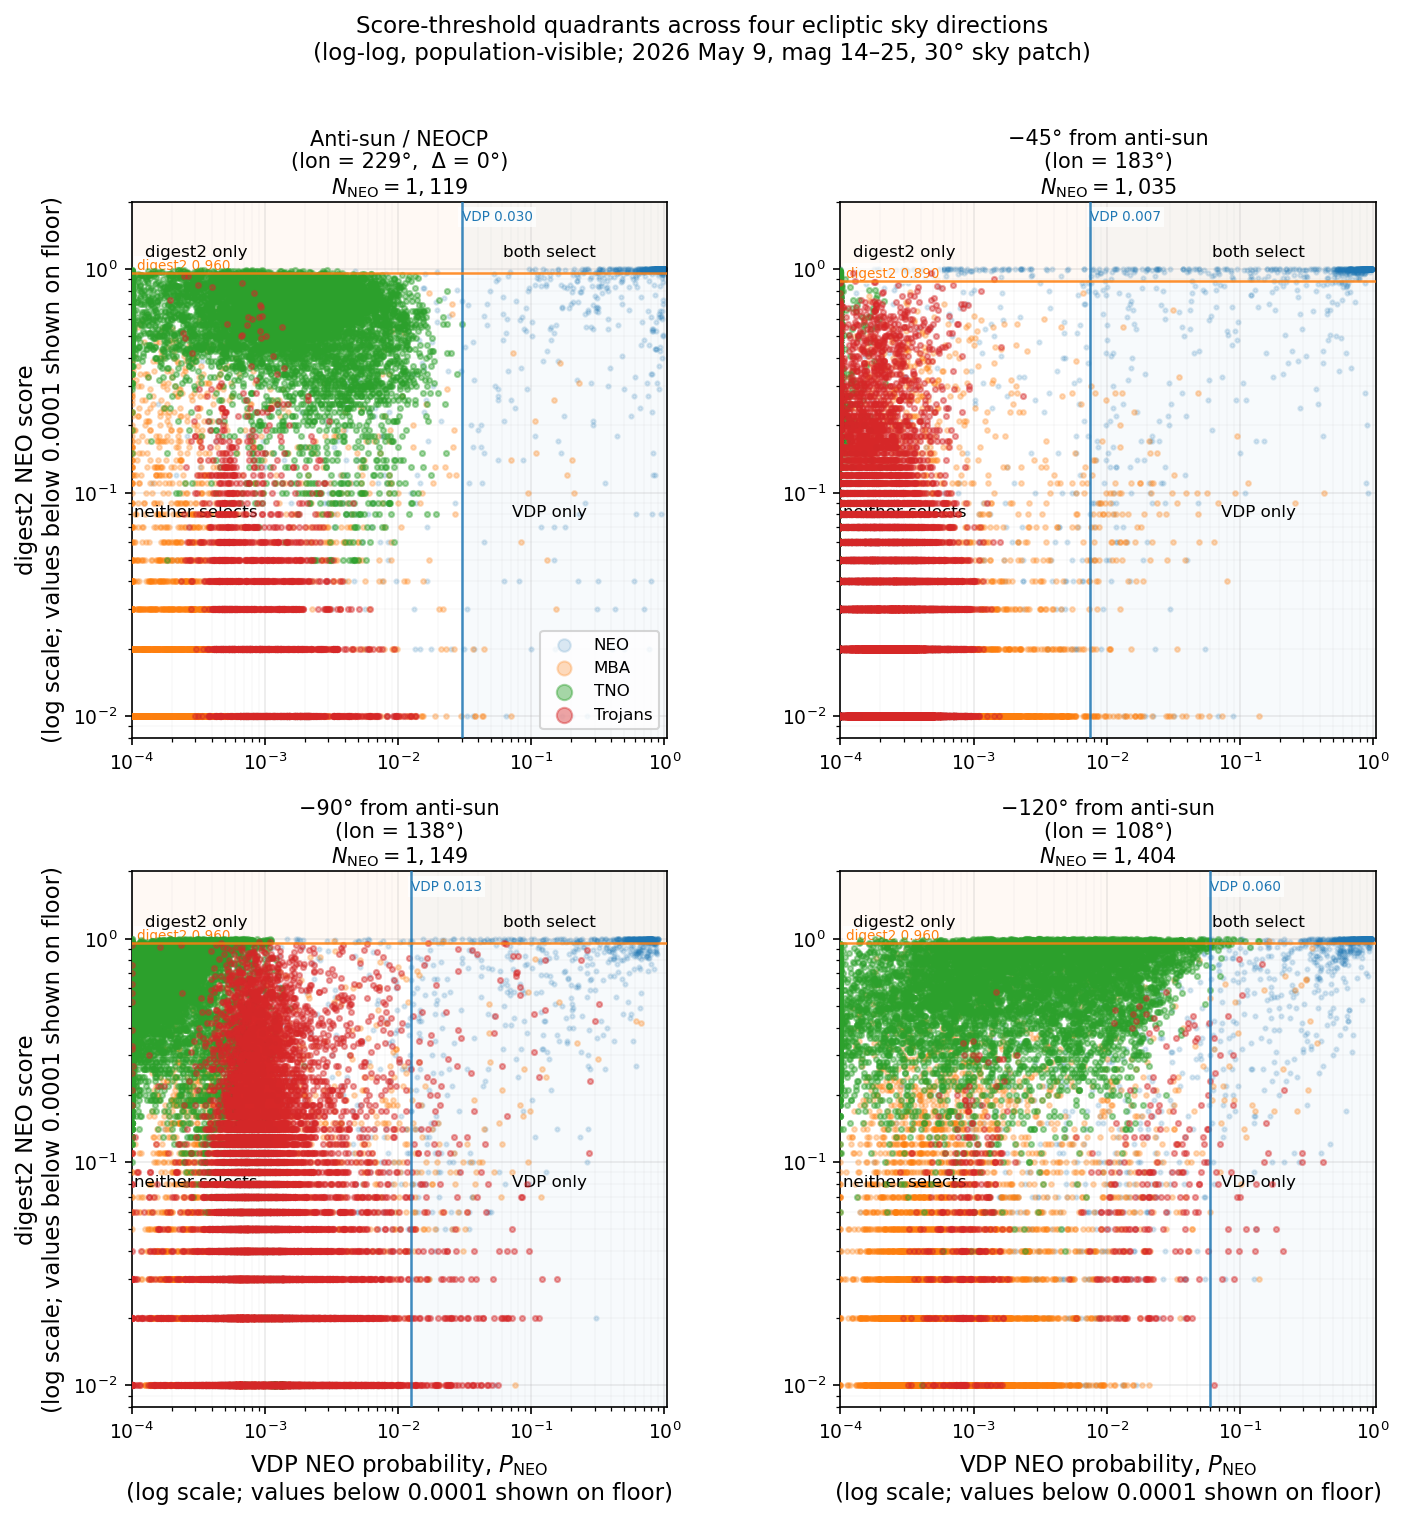

In [6]:
SCORE_FLOOR = 1e-4
Y_LOW       = 8e-3
X_HIGH      = 1.05
Y_HIGH      = 2.0

PLOT_STYLE = {
    'NEO':     dict(s=4,  alpha=0.16, zorder=2),
    'MBA':     dict(s=5,  alpha=0.28, zorder=3),
    'TNO':     dict(s=6,  alpha=0.42, zorder=5),
    'Trojans': dict(s=6,  alpha=0.42, zorder=6),
}

from matplotlib.transforms import blended_transform_factory

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes_flat = axes.flatten()

for run in RUNS:
    ax  = axes_flat[run['panel_idx']]
    row, col = divmod(run['panel_idx'], 2)
    df  = run['df']
    tv  = run['tv']
    td  = run['td']

    x_vis = np.clip(df['P_NEO_vdp'].to_numpy(), SCORE_FLOOR, 1.0)
    y_vis = np.clip(df['P_NEO_d2'].to_numpy(),  SCORE_FLOOR, 1.0)

    for pop in ['NEO', 'MBA', 'TNO', 'Trojans']:
        if pop not in df['true_population'].values:
            continue
        mask = (df['true_population'] == pop).to_numpy()
        ax.scatter(
            x_vis[mask], y_vis[mask],
            label=pop,
            color=COLORS[pop],
            rasterized=True,
            **PLOT_STYLE[pop],
        )

    ax.axvline(tv, color='tab:blue',   lw=1.2, alpha=0.85, zorder=8)
    ax.axhline(td, color='tab:orange', lw=1.2, alpha=0.85, zorder=8)
    ax.axvspan(tv, X_HIGH, color='tab:blue',   alpha=0.03, zorder=0)
    ax.axhspan(td, Y_HIGH, color='tab:orange', alpha=0.045, zorder=0)

    _bbox = dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5)

    # VDP vertical line: label at the TOP of the line, just to its right.
    # Blended: x tracks the line in data/log coords, y pinned to top of axes.
    _tx = blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(tv, 0.985, f'VDP {tv:.3f}',
            transform=_tx, color='tab:blue', fontsize=6.5,
            ha='left', va='top', bbox=_bbox)

    # digest2 horizontal line: label at the LEFT edge of the axes, just above
    # the line. Blended: x pinned to left edge of axes, y tracks line in data.
    _ty = blended_transform_factory(ax.transAxes, ax.transData)
    ax.text(0.01, td, f'digest2 {td:.3f}',
            transform=_ty, color='tab:orange', fontsize=6.5,
            ha='left', va='bottom', bbox=_bbox)

    # Quadrant labels — mid-panel positions, clear of threshold annotations
    ax.text(0.78, 0.92, 'both select',     transform=ax.transAxes, fontsize=8, ha='center', va='top')
    ax.text(0.78, 0.42, 'VDP only',        transform=ax.transAxes, fontsize=8, ha='center', va='center')
    ax.text(0.12, 0.92, 'digest2 only',    transform=ax.transAxes, fontsize=8, ha='center', va='top')
    ax.text(0.12, 0.42, 'neither selects', transform=ax.transAxes, fontsize=8, ha='center', va='center')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(SCORE_FLOOR, X_HIGH)
    ax.set_ylim(Y_LOW, Y_HIGH)
    ax.set_box_aspect(1)
    ax.set_title(f"{run['title']}\n$N_{{\\mathrm{{NEO}}}}={run['n_neo']:,}$", pad=4)
    ax.grid(alpha=0.25, which='major')
    ax.grid(alpha=0.07, which='minor')

    if row == 1:
        ax.set_xlabel(
            f'VDP NEO probability, $P_{{\\mathrm{{NEO}}}}$\n'
            f'(log scale; values below {SCORE_FLOOR:g} shown on floor)'
        )
    if col == 0:
        ax.set_ylabel(
            f'digest2 NEO score\n'
            f'(log scale; values below {SCORE_FLOOR:g} shown on floor)'
        )

    if run['panel_idx'] == 0:
        ax.legend(loc='lower right', frameon=True, markerscale=3)

fig.suptitle(
    'Score-threshold quadrants across four ecliptic sky directions\n'
    '(log-log, population-visible; 2026 May 9, mag 14–25, 30° sky patch)',
    fontsize=11, y=1.01,
)
plt.tight_layout()

fig_out_quad_png = os.path.join(_HERE, 'quadrant_4panel_directions.png')
fig_out_quad_pdf = os.path.join(_HERE, 'quadrant_4panel_directions.pdf')
fig.savefig(fig_out_quad_png)
fig.savefig(fig_out_quad_pdf)
print(f'Saved: {fig_out_quad_png}')
print(f'Saved: {fig_out_quad_pdf}')
plt.show()
plt.close(fig)